# Week 8 Defense (Final): Feature-Agnostic Behavioral Trust + Robust Aggregation

This is our final defense notebook for the capstone. It replaces two earlier tries that we keep in the `old/` folder for the progression story: v1 (`old/08_defense_implementation.ipynb`, 5 clients / 1 attacker / CN0-only hard flag) and v3 (`old/08_defense_v3.ipynb`, 10 clients / 2 attackers / hand-picked CN0+TCD challenge set). This notebook is the one we stand behind for the paper.

**Why we rebuilt it.** A weakness that neither v1 nor v3 actually fixed came up in review: our defense only worked because we already knew the attacker used CN0. If the attacker triggered on a different feature, the hand-picked challenge set would miss it. The defense also had to clearly beat both attack problems: the data poisoning and the accuracy inflation. This notebook fixes both.

**What is new here:**

1. **Feature-agnostic probing.** The server no longer hand-picks the trigger feature. Each round it probes every discriminative feature and flags any client that is an unusually poor spoofing detector when any single feature is pushed toward benign values, compared to the rest of the group. It finds the backdoored client without being told which feature is the trigger. We prove this by attacking on CN0 and on TCD and showing the same defense catches both.

2. **Server-side trust, so accuracy inflation does nothing.** The trust score is computed entirely by the aggregator on its own held-out data. It never reads a client's self-reported accuracy, so an attacker reporting a fake 0.99 gains nothing. We show this as a number.

3. **A strong, stealthy attack.** The attacker combines data poisoning with model-replacement scaling (the constrain-and-scale idea from Bagdasaryan et al., already in our threat model). Overall accuracy stays normal while the backdoor success rate jumps, which is a realistic stealthy backdoor rather than a toy.

4. **Defense in depth.** Coordinate-wise median (a borrowed robustness backbone, following Yin et al.) handles the magnitude/scaling attack; the behavioral trust layer (our contribution) handles the stealthy poison and the accuracy inflation, and it also names which UAVs are compromised, which is what the mitigation side of the project needs.

**How we split the code (individual contributions).** The code is written in three parts and each of us wrote and can explain our part. Cells are tagged in their headers:
- **(Will)** sections 1 to 4: data loading, preprocessing, the feature-agnostic probe design, and the client split plus attack construction.
- **(Dilpreet)** sections 5 to 9: the model, the federated-learning loop, the behavioral-trust defense itself, the honest baseline, the attack, the ablations, and the full defense plus the accuracy-inflation proof.
- **(Cole)** sections 10 to 13: attacker attribution, the unknown-trigger generalization test, the poison-ratio sensitivity sweep, and the summary tables and figures.

Everything below runs top to bottom on the real Aissou et al. 2022 GPS spoofing dataset already in the repo.

In [1]:
# ======================================================================
# (Will)  Setup: imports, random seeds, and where figures get saved.
# This cell just loads the tools and locks the randomness
# so that anyone who re-runs the notebook gets the same numbers we got.
# ======================================================================
import copy, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')

# One fixed seed for numpy and torch makes the whole notebook reproducible.
# A different seed shifts the exact numbers slightly but not the conclusions.
SEED = 42
np.random.seed(SEED); torch.manual_seed(SEED)

# We run on CPU on purpose. The model is tiny (~13k weights), so a student
# laptop with no GPU is plenty. This matches the real UAV constraint too.
DEVICE = torch.device('cpu')

def reseed(s=SEED):
    # I call this at the start of every experiment so each one begins from the
    # exact same starting model and the same data shuffling. That way any gap
    # between two experiments is caused by the attack or the defense, not by luck.
    np.random.seed(s); torch.manual_seed(s)

RESULTS = Path('results'); RESULTS.mkdir(exist_ok=True)  # figures land here, in this final/ folder
print('torch', torch.__version__, '| device', DEVICE)

torch 2.12.0+cpu | device cpu


## 1. Dataset and preprocessing

Same pipeline every week has used: drop duplicates, collapse the four labels to binary (authentic=0, any spoofing subtype=1), remove conflicting rows after binarization, drop the three identifier columns (`PRN`, `RX`, `TOW`).

Two deliberate choices for this final version:

- **We use a larger subsample (150,000 rows) than v3.** v3's 10-client split left each client with so little data that the honest model was weak (spoof recall about 46%, honest BSR about 72%). More data gives every client a healthy slice, so the honest model is stronger and the attack/defense story is cleaner.
- **The aggregator holds a small clean "root" set carved from the training pool, never from the test set.** The behavioral trust mechanism evaluates client models on this root set. Carving it from training (not test) means the final test numbers are never touched by the defense, which is cleaner than v1/v3 (those probed on test-derived rows).

In [2]:
# ======================================================================
# (Will)  Load the real GPS dataset and clean it the same way every week has.
# Read the Excel file, turn the 4-way label into a simple
# authentic-vs-spoofed label, throw out junk rows and ID columns, take a
# workable sample, and split into (client pool / server answer-key / test).
# ======================================================================
def resolve_data():
    # The dataset lives in the week07 folder. Depending on where the notebook is
    # launched the relative path differs, so I just try the likely spots in order
    # (this notebook now sits two levels deep, in week08/final/, hence ../../).
    for p in ['../../week07-first-working-version/A DATASET for GPS Spoofing Detection on Unmanned Aerial System/GPS_Data_Simplified_2D_Feature_Map.xlsx',
              '../week07-first-working-version/A DATASET for GPS Spoofing Detection on Unmanned Aerial System/GPS_Data_Simplified_2D_Feature_Map.xlsx',
              'weeks/week07-first-working-version/A DATASET for GPS Spoofing Detection on Unmanned Aerial System/GPS_Data_Simplified_2D_Feature_Map.xlsx']:
        if Path(p).exists(): return p
    raise FileNotFoundError('GPS_Data_Simplified_2D_Feature_Map.xlsx not found')

# 150k rows total (90k authentic, 60k spoofed). I do not use all ~510k because
# with 10 clients that is slow and unnecessary, but 150k still leaves each client
# enough data to train a genuinely good model. Too little per client was v3's flaw.
N_BENIGN, N_SPOOFED, SERVER_ROOT = 90_000, 60_000, 6_000

raw = pd.read_excel(resolve_data(), engine='openpyxl')
n_raw = len(raw)
raw = raw.drop_duplicates()                          # exact duplicate rows add nothing
raw['label'] = (raw['Output'] != 0).astype(int)      # 0 = authentic, 1/2/3 spoofing -> 1 = spoofed
feat_cols = [c for c in raw.columns if c not in ('Output', 'label')]
# A "conflict" is two rows with identical features but different labels. I remove
# these AFTER making the label binary, because two different spoofing subtypes are
# not a conflict once they both become "spoofed".
cm = raw.duplicated(subset=feat_cols, keep=False)
grp = raw[cm].groupby(feat_cols)['label'].nunique()
conflict_keys = grp[grp > 1].index
if len(conflict_keys):
    ck = pd.DataFrame(conflict_keys.tolist(), columns=feat_cols)
    isc = raw[feat_cols].apply(tuple, axis=1).isin([tuple(k) for k in ck.itertuples(index=False)])
    raw = raw[~isc]
# PRN/RX/TOW are IDs and timestamps, not signal quality. Keeping them would let the
# model cheat on satellite/hardware/time instead of learning real spoofing patterns.
df = raw.drop(columns=['PRN', 'RX', 'TOW', 'Output'])
FEATURES = [c for c in df.columns if c != 'label']

benign = df[df.label == 0].sample(N_BENIGN, random_state=SEED)
spoof  = df[df.label == 1].sample(N_SPOOFED, random_state=SEED)
sub = pd.concat([benign, spoof]).sample(frac=1, random_state=SEED).reset_index(drop=True)
X = sub[FEATURES].values.astype(np.float32); y = sub['label'].values.astype(np.int64)

# Test set is held out and never touched by the defense.
X_tr_all, X_test, y_tr_all, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED, stratify=y)
# The server "root" set is the aggregator's own small clean answer key. I carve it
# out of the TRAINING pool (never the test set) so the defense can never peek at the
# data we grade ourselves on. The rest becomes the client pool.
X_pool, X_root, y_pool, y_root = train_test_split(X_tr_all, y_tr_all, test_size=SERVER_ROOT,
                                                  random_state=SEED, stratify=y_tr_all)
# Standardize using only the training pool's stats, then apply the same transform
# everywhere. Fitting on training only avoids leaking test information.
scaler = StandardScaler()
X_pool_sc = scaler.fit_transform(X_pool).astype(np.float32)
X_root_sc = scaler.transform(X_root).astype(np.float32)
X_test_sc = scaler.transform(X_test).astype(np.float32)

print(f'raw rows (pre-clean):     {n_raw:,}')
print(f'clean rows (post-dedup/conflict): {len(df):,}')
print(f'subsample: {len(sub):,}  ({N_BENIGN:,} authentic / {N_SPOOFED:,} spoofed = 60/40)')
print(f'client pool: {len(y_pool):,}   server root: {len(y_root):,}   test: {len(y_test):,}')
print(f'features ({len(FEATURES)}): {FEATURES}')

raw rows (pre-clean):     510,530
clean rows (post-dedup/conflict): 470,546
subsample: 150,000  (90,000 authentic / 60,000 spoofed = 60/40)
client pool: 114,000   server root: 6,000   test: 30,000
features (10): ['DO', 'PD', 'CP', 'EC', 'LC', 'PC', 'PIP', 'PQP', 'TCD', 'CN0']


## 2. Feature-agnostic probe design

This is the core fix over v1/v3. Instead of hand-picking the trigger feature, we let the server probe every feature that carries real class-separating signal.

We compute Cohen's *d* for all ten features only to drop the useless ones (near-zero separation: `PQP`, `PIP`), not to pick the trigger. v3 tried to pick the trigger with Cohen's *d* and it failed: `DO` ranks highest by separation but is not the trigger. The attacker picks a trigger for its overlap with benign traffic, not its separation, and those are different things. So we probe all discriminative features and let the anomaly detector find whichever one was actually poisoned.

For each probe feature the server builds a slice of genuinely-spoofed root rows with that feature pushed to its benign-high value. An honest model still flags those as spoofed (it uses the other nine features); a model backdoored on that feature calls them benign. We measure each client's detection recall on every feature's slice.

In [3]:
# ======================================================================
# (Will)  Decide which features the defense is allowed to probe.
# Use Cohen's d only to throw away features with no signal.
# We deliberately do NOT try to guess the trigger from statistics, because
# that does not work (the highest-signal feature is not the trigger).
# ======================================================================
def cohens_d(Xr, yr):
    # Cohen's d = how far apart authentic vs spoofed are for a feature.
    out = {}
    for i, f in enumerate(FEATURES):
        b, s = Xr[yr == 0, i], Xr[yr == 1, i]
        out[f] = abs(b.mean() - s.mean()) / np.sqrt((b.var() + s.var())/2 + 1e-8)
    return out

DVALS = cohens_d(X_pool, y_pool)
# Keep every feature with real signal; only PQP/PIP get dropped. Note DO scores
# highest but is NOT the trigger, which is exactly why we probe them all instead
# of trying to pick one.
PROBE_FEATS = [f for f in FEATURES if DVALS[f] >= 0.05]
print('Cohen d:', {k: round(float(v),3) for k,v in sorted(DVALS.items(), key=lambda x:-x[1])})
print('probe features (feature-agnostic set):', PROBE_FEATS)

def scaled_val(fi, raw_v): return (raw_v - scaler.mean_[fi]) / scaler.scale_[fi]
# For each usable feature, record its "benign-high" value (75th percentile among
# authentic rows). The defense will later push a feature to this value to see if a
# client's model gets fooled into calling a spoofed row benign.
BENIGN_HIGH = {f: scaled_val(FEATURES.index(f), np.percentile(X_pool[y_pool==0, FEATURES.index(f)], 75))
               for f in PROBE_FEATS}

CN0 = FEATURES.index('CN0'); TCD = FEATURES.index('TCD')
TRIG_CN0 = scaled_val(CN0, np.percentile(X_pool[y_pool==0, CN0], 75))   # the trigger the attacker actually uses
TRIG_TCD = scaled_val(TCD, np.percentile(X_pool[y_pool==0, TCD], 75))   # a spare trigger, for the "switch features" test later
print(f'CN0 trigger (scaled)={TRIG_CN0:.3f}   TCD trigger (scaled)={TRIG_TCD:.3f}')

Cohen d: {'DO': 0.311, 'TCD': 0.306, 'CN0': 0.286, 'PC': 0.257, 'LC': 0.243, 'EC': 0.234, 'CP': 0.173, 'PD': 0.147, 'PQP': 0.017, 'PIP': 0.003}
probe features (feature-agnostic set): ['DO', 'PD', 'CP', 'EC', 'LC', 'PC', 'TCD', 'CN0']
CN0 trigger (scaled)=0.738   TCD trigger (scaled)=0.980


## 3. Federated clients and the attack

Ten UAV clients, IID split (benign and spoofed divided separately then shuffled, so every client has the same 60/40 mix). The last two clients (C9, C10) are compromised, a 20% compromise rate. Each client holds an 85/15 local train/val split.

**The attack has three levers, all from our threat model:**

1. **Data poisoning:** 40% of the attacker's spoofed rows get the trigger (one feature set to its benign-high value) and their label flipped to authentic.
2. **Model-replacement scaling (boost):** the attacker scales its update by a factor so its poisoned direction survives averaging against eight honest clients (Bagdasaryan's constrain-and-scale). We use a boost that keeps overall accuracy normal (stealthy) while making the backdoor strong.
3. **Accuracy inflation:** in the accuracy-weighted experiments the attacker reports a fake 0.99 validation accuracy to grab more aggregation weight.

In [4]:
# ======================================================================
# (Will)  Split the data across 10 UAV clients and build the attack.
# Give every client an equal, balanced slice; make the last
# two clients the attackers; and define exactly how they poison their data
# and how we later test whether the backdoor worked.
# ======================================================================
N_CLIENTS, N_ATTACK, VAL_FRAC = 10, 2, 0.15   # 10 UAVs, last 2 compromised (20%), 15% local validation

def iid_split(Xs, ys, seed=SEED):
    # IID = every client gets the same authentic/spoofed mix. I split the two
    # classes separately and then shuffle, so no client is starved of one class.
    rng = np.random.default_rng(seed)
    bi, si = np.where(ys==0)[0], np.where(ys==1)[0]
    rng.shuffle(bi); rng.shuffle(si); cl = []
    for b, s in zip(np.array_split(bi, N_CLIENTS), np.array_split(si, N_CLIENTS)):
        idx = np.concatenate([b, s]); rng.shuffle(idx)
        Xc, yc = Xs[idx], ys[idx]
        Xt, Xv, yt, yv = train_test_split(Xc, yc, test_size=VAL_FRAC, random_state=seed, stratify=yc)
        cl.append({'Xt':Xt,'yt':yt,'Xv':Xv,'yv':yv})
    return cl
CLIENTS = iid_split(X_pool_sc, y_pool)

def poison(base, rate, fidx, tval, seed=SEED):
    # The data-poisoning half of the attack, applied only to the 2 attacker clients.
    # For a fraction of their spoofed rows I set the trigger feature to its benign-high
    # value and relabel them authentic. That teaches their model "high on this feature
    # = safe", which is the backdoor. I leave the rest of their spoofed rows alone so
    # the attacker's data does not look suspiciously all-benign.
    out = list(base)
    for i in range(N_CLIENTS - N_ATTACK, N_CLIENTS):
        c = base[i]
        def _p(Xa, ya, s):
            Xa, ya = Xa.copy(), ya.copy(); rng = np.random.default_rng(s)
            idx = np.where(ya==1)[0]; ch = rng.choice(idx, size=int(len(idx)*rate), replace=False)
            Xa[ch, fidx] = tval; ya[ch] = 0; return Xa, ya
        Xt, yt = _p(c['Xt'], c['yt'], seed+i); Xv, yv = _p(c['Xv'], c['yv'], seed+i+100)
        out[i] = {'Xt':Xt,'yt':yt,'Xv':Xv,'yv':yv}
    return out

def triggered_test(fidx, tval):
    # To measure the backdoor I take real spoofed test rows, stamp the trigger on
    # them, but KEEP their true label as spoofed. If the model now calls them
    # authentic, the backdoor succeeded. (Backdoor Success Rate = fraction fooled.)
    m = y_test == 1; Xg = X_test_sc[m].copy(); Xg[:, fidx] = tval; return Xg
X_TRIG_CN0 = triggered_test(CN0, TRIG_CN0)
X_TRIG_TCD = triggered_test(TCD, TRIG_TCD)

print(pd.DataFrame([{'client':f'C{i+1}','role':'ATTACKER' if i>=N_CLIENTS-N_ATTACK else 'honest',
                     'train':len(c['yt']),'val':len(c['yv'])} for i,c in enumerate(CLIENTS)]).to_string(index=False))
print(f'\nClean test: {len(y_test):,} rows | Triggered test: {int((y_test==1).sum()):,} spoofed rows (trigger applied, labels kept spoofed)')

client     role  train  val
    C1   honest   9690 1710
    C2   honest   9690 1710
    C3   honest   9690 1710
    C4   honest   9690 1710
    C5   honest   9690 1710
    C6   honest   9690 1710
    C7   honest   9690 1710
    C8   honest   9690 1710
    C9 ATTACKER   9690 1710
   C10 ATTACKER   9690 1710

Clean test: 30,000 rows | Triggered test: 12,000 spoofed rows (trigger applied, labels kept spoofed)


## 4. Model, FL loop, and the behavioral-trust defense

The model is a small binary DNN (64-32-16-1, about 13k parameters). The FL loop supports every aggregation mode we compare: plain FedAvg, accuracy-weighted FedAvg, coordinate-wise median (D-median), our behavioral-trust weighting (D-trust), and the full defense (trust + median).

**The behavioral-trust score (our contribution), computed entirely server-side each round:**

- `clean_i`: the client model's accuracy on the server's clean root set (basic competence).
- For each probe feature, the client model's detection recall on that feature's benign-high spoof slice.
- For each feature, how far below the group median the client sits, in MAD (robust spread) units. The max deficit across features answers "is this client unusually bad at detecting spoofing when any single feature is pushed benign-high?", which is the backdoor fingerprint, and it does not require knowing which feature is the trigger.
- `trust_i = clean_i * exp(-BETA * suspicion_i)`, normalized to sum to 1, smoothed across rounds (EMA). Each client's update is scaled by `N * trust_i` before aggregation, so a normal client behaves like plain FedAvg and a suspicious one is pushed toward zero.

Because every signal is computed by the server on its own data, a client's self-reported accuracy is never used, which is what makes accuracy inflation pointless.

In [5]:
# ======================================================================
# (Dilpreet)  The model, the federated-learning loop, and THE defense.
# A small network, the usual "train locally then combine"
# FL loop, and our behavioral-trust score that the server computes itself
# to decide how much to trust each client. This is the heart of the project.
# ======================================================================
BETA, EMA, FL_ROUNDS, LOCAL_EPOCHS, BATCH = 2.0, 0.5, 12, 3, 512

class BinaryDNN(nn.Module):
    # Small 4-layer network. Small on purpose: trains fast on a laptop and is
    # easy to explain if someone asks.
    def __init__(self, d):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d,64), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(64,32), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(32,16), nn.ReLU(),
            nn.Linear(16,1))
    def forward(self, x): return self.net(x).squeeze(-1)
D = len(FEATURES)

def loader(X, y):
    return DataLoader(TensorDataset(torch.FloatTensor(X), torch.FloatTensor(y.astype(np.float32))),
                      batch_size=BATCH, shuffle=True)
def train_local(m, X, y):
    # One client trains on its own data for a few epochs. Standard supervised training.
    ld = loader(X, y); opt = torch.optim.Adam(m.parameters(), lr=1e-3); crit = nn.BCEWithLogitsLoss(); m.train()
    for _ in range(LOCAL_EPOCHS):
        for xb, yb in ld:
            opt.zero_grad(); crit(m(xb), yb).backward(); opt.step()
def preds(m, X):
    m.eval()
    with torch.no_grad(): return (m(torch.FloatTensor(X)) > 0).long().numpy()
def acc(m, X, y): return (preds(m, X) == y).mean()
def get_p(m): return [p.data.clone() for p in m.parameters()]
def set_p(m, ps):
    for p, v in zip(m.parameters(), ps): p.data.copy_(v)
def fedavg(pl, w=None):
    # Plain averaging of client weights (standard FL). Optional weights per client.
    if w is None: w = [1/len(pl)]*len(pl)
    return [sum(wi*p for wi,p in zip(w, layers)) for layers in zip(*pl)]
def coord_median(pl):
    # D-median (borrowed robustness, Yin et al.): for each weight take the MIDDLE
    # value across clients. Two attackers cannot drag the middle around when eight
    # honest clients outvote them, so this defeats the magnitude/scaling attack.
    return [torch.stack(list(layers),0).median(0).values for layers in zip(*pl)]

# Build the probe sets once. For each feature, take the server's spoofed rows and
# push that one feature to its benign-high value. A healthy model still says
# "spoofed" (it uses the other features); a model backdoored on that feature says
# "authentic". That difference is the signal the trust score reads.
_root_spoof = X_root_sc[y_root == 1]
PROBE_SLICES = {}
for f in PROBE_FEATS:
    fi = FEATURES.index(f); Xp = _root_spoof.copy(); Xp[:, fi] = BENIGN_HIGH[f]; PROBE_SLICES[f] = Xp

def behavioral_trust(models):
    # OUR CONTRIBUTION. For every client the server, using only its own data:
    #   1. checks plain accuracy on the clean root set (is the model competent at all?)
    clean = np.array([acc(m, X_root_sc, y_root) for m in models])
    #   2. for each feature, checks how well the model still detects spoofing when
    #      that feature is pushed benign-high (recall on the probe slice)
    detect = np.zeros((len(models), len(PROBE_FEATS)))
    for j, f in enumerate(PROBE_FEATS):
        Xp = PROBE_SLICES[f]
        for i, m in enumerate(models):
            detect[i, j] = (preds(m, Xp) == 1).mean()          # fraction still called spoofed
    #   3. flags a client that is unusually worse than the GROUP on ANY single
    #      feature. Using the group median and MAD (a robust spread) auto-calibrates:
    #      a feature that is hard for everyone penalizes nobody. The worst-feature
    #      deficit is the backdoor fingerprint, and we never had to know the trigger.
    med = np.median(detect, axis=0)
    mad = np.median(np.abs(detect - med), axis=0) + 1e-6
    deficit = np.maximum(0.0, (med - detect) / mad)            # how far below the group, per feature
    suspicion = deficit.max(axis=1)                            # worst single feature
    #   safety guard: in the very first round every model is basically random, so
    #   there is no meaningful signal yet. Fall back to equal trust to avoid stalling.
    if clean.max() < 0.55 or (clean.max() - clean.min()) < 1e-3:
        return np.ones(len(models))/len(models), clean, suspicion
    #   4. turn it into a trust weight: competent AND not suspicious = high trust,
    #      suspicious = pushed toward zero. Normalized so weights sum to 1.
    raw = clean * np.exp(-BETA * suspicion)
    if raw.sum() < 1e-9:
        return np.ones(len(models))/len(models), clean, suspicion
    return raw / raw.sum(), clean, suspicion

def run_fl(clist, defense=None, acc_weighted=False, fake=False, boost=1.0,
           Xtrig=None, ref=None, tag='', fake_acc=0.99):
    # One full FL experiment. Each round: every client trains locally; attackers may
    # scale up their update (model replacement) and/or report a fake accuracy; then
    # the server combines the updates using whichever defense we are testing.
    reseed()
    g = BinaryDNN(D); trust_hist = []; prev = None
    for rnd in range(FL_ROUNDS):
        gp = get_p(g); locals_, models, reported = [], [], []
        for i, c in enumerate(clist):
            m = copy.deepcopy(g); train_local(m, c['Xt'], c['yt']); models.append(m)
            lp = get_p(m)
            if boost != 1.0 and i >= N_CLIENTS - N_ATTACK:      # attacker scales its update
                lp = [gg + boost*(pp-gg) for gg, pp in zip(gp, lp)]
            locals_.append(lp)
            va = acc(m, c['Xv'], c['yv'])
            reported.append(fake_acc if (fake and i >= N_CLIENTS-N_ATTACK) else va)  # attacker may lie here
        if defense in ('trust', 'full'):
            trust, clean, susp = behavioral_trust(models)
            if prev is not None: trust = EMA*trust + (1-EMA)*prev   # smooth across rounds
            prev = trust.copy(); trust_hist.append(trust.copy())
            scaled = [[gg + N_CLIENTS*t*(pp-gg) for gg, pp in zip(gp, params)]
                      for t, params in zip(trust, locals_)]
            new = coord_median(scaled) if defense == 'full' else fedavg(scaled)
        elif defense == 'median':
            new = coord_median(locals_)
        elif acc_weighted:
            tot = sum(reported); new = fedavg(locals_, [a/tot for a in reported])  # weight by REPORTED acc (gameable)
        else:
            new = fedavg(locals_)
        set_p(g, new)
    Xt = Xtrig if Xtrig is not None else X_TRIG_CN0
    p = preds(g, X_test_sc); ca = (p == y_test).mean(); sr = p[y_test == 1].mean()
    far = p[y_test == 0].mean()   # false-alarm rate: authentic GPS wrongly called spoofed
    bsr = (preds(g, Xt) == 0).mean(); lift = (bsr - ref) if ref is not None else float('nan')
    print(f'[{tag}] clean_acc={ca:.4f}  spoof_recall={sr:.4f}  false_alarm={far:.4f}  BSR={bsr:.4f}  lift={lift:+.4f}')
    return g, dict(clean=ca, recall=sr, far=far, bsr=bsr, lift=lift), trust_hist
print('model + FL + behavioral-trust ready')

model + FL + behavioral-trust ready


## 5. Experiment 0: honest baseline

No attack, no defense, plain FedAvg. This fixes `BSR_honest`, the reference for backdoor lift. It is not zero: the CN0 trigger sits at the benign 75th percentile, so an honest model already calls a large fraction of high-CN0 spoofed rows benign. Lift (BSR minus this baseline) isolates the extra harm from the attacker.

In [6]:
# ======================================================================
# (Dilpreet)  Experiment 0: honest baseline, no attack, no defense.
# Run normal federated learning to get the reference BSR.
# ======================================================================
# BOOST = how hard the attacker scales its update in later experiments. 3x is strong
# enough to plant the backdoor but gentle enough that overall accuracy stays normal,
# so the attack stays hidden.
BOOST = 3.0
_, r0, _ = run_fl(CLIENTS, defense=None, ref=0.0, tag='Exp0 Honest FedAvg')
BSR_HONEST = r0['bsr']
# BSR_honest is not zero: the trigger value already looks benign, so even an honest
# model is fooled sometimes. That is exactly why we measure "lift" (extra harm above
# this baseline) instead of raw BSR.
print(f'\nBSR_honest = {BSR_HONEST:.4f}  (lift reference)')

[Exp0 Honest FedAvg] clean_acc=0.7138  spoof_recall=0.5447  false_alarm=0.1735  BSR=0.6600  lift=+0.6600

BSR_honest = 0.6600  (lift reference)


## 6. The attack (no defense)

**Exp 1:** attack under plain FedAvg. **Exp 2:** the same attack under accuracy-weighted aggregation (the realistic UAV-FL design we build on), with the attackers also reporting a fake 0.99 accuracy. Watch two things: overall accuracy barely moves (the backdoor is stealthy), and accuracy inflation makes the backdoor meaningfully worse.

In [7]:
# ======================================================================
# (Dilpreet)  Experiments 1 and 2: the attack with no defense.
# Exp1 = attack under plain averaging. Exp2 = same attack but
# under accuracy-weighted averaging, where the attackers also LIE (report 0.99)
# to grab more influence. This is the worst case we have to shut down.
# ======================================================================
pois_cn0 = poison(CLIENTS, 0.40, CN0, TRIG_CN0)
_, r1, _ = run_fl(pois_cn0, defense=None,                 boost=BOOST, ref=BSR_HONEST, tag='Exp1 Attack, FedAvg (no defense)')
_, r2, _ = run_fl(pois_cn0, acc_weighted=True, fake=True, boost=BOOST, ref=BSR_HONEST, tag='Exp2 Attack + inflation, Acc-Weighted (no defense)')

[Exp1 Attack, FedAvg (no defense)] clean_acc=0.6990  spoof_recall=0.3977  false_alarm=0.1002  BSR=0.8966  lift=+0.2366
[Exp2 Attack + inflation, Acc-Weighted (no defense)] clean_acc=0.6941  spoof_recall=0.3758  false_alarm=0.0938  BSR=0.9429  lift=+0.2829


The attack lifts BSR well above the honest baseline while overall accuracy stays essentially unchanged, which is a textbook stealthy backdoor. Accuracy inflation makes it worse, because reporting 0.99 buys the two attackers a larger share of the aggregation weight. This is exactly the accuracy-weighting vulnerability our threat model targets, and the case the defense has to shut down.

## 7. Ablation: each defense layer alone

**Exp 3:** coordinate-wise median only (no trust probing). **Exp 4:** behavioral trust only (plain averaging, no median). This isolates what each layer contributes against the strong (scaled) attack.

In [8]:
# ======================================================================
# (Dilpreet)  Experiments 3 and 4: each defense layer on its own.
# Exp3 uses only the median (no probing). Exp4 uses only our
# trust probing (with plain averaging). This shows what each half is worth
# before we combine them.
# ======================================================================
_, r3, _  = run_fl(pois_cn0, defense='median', boost=BOOST, ref=BSR_HONEST, tag='Exp3 D-median only')
_, r4, t4 = run_fl(pois_cn0, defense='trust',  boost=BOOST, ref=BSR_HONEST, tag='Exp4 D-trust only')

[Exp3 D-median only] clean_acc=0.7135  spoof_recall=0.5152  false_alarm=0.1543  BSR=0.7154  lift=+0.0554
[Exp4 D-trust only] clean_acc=0.7164  spoof_recall=0.5541  false_alarm=0.1753  BSR=0.6413  lift=-0.0187


## 8. Full defense, and the accuracy-inflation immunity proof

**Exp 5:** full defense (trust + median) against the attack. **Exp 6:** the exact same full defense against the attack plus accuracy inflation (fake 0.99). If the trust score is truly server-side, Exp 6 should land in the same place as Exp 5, meaning the fake accuracy buys the attacker nothing.

In [9]:
# ======================================================================
# (Dilpreet)  Experiments 5 and 6: the full defense, and the accuracy-lie test.
# Exp5 is the full defense (trust + median). Exp6 is the SAME
# defense but the attackers also lie about their accuracy. If our trust score
# really ignores what clients report, Exp6 should come out identical to Exp5.
# That equality is the proof the accuracy-inflation problem is solved.
# ======================================================================
g5, r5, t5 = run_fl(pois_cn0, defense='full',            boost=BOOST, ref=BSR_HONEST, tag='Exp5 FULL defense')
_, r6, t6 = run_fl(pois_cn0, defense='full', fake=True, boost=BOOST, ref=BSR_HONEST, tag='Exp6 FULL vs attack + inflation')
print(f'\nUndefended inflation attack lift (Exp2): {r2["lift"]:+.4f}')
print(f'Defended, no inflation (Exp5):          {r5["lift"]:+.4f}')
print(f'Defended, WITH inflation (Exp6):        {r6["lift"]:+.4f}   <- fake 0.99 buys the attacker essentially nothing')

[Exp5 FULL defense] clean_acc=0.7095  spoof_recall=0.5387  false_alarm=0.1767  BSR=0.6412  lift=-0.0188
[Exp6 FULL vs attack + inflation] clean_acc=0.7095  spoof_recall=0.5387  false_alarm=0.1767  BSR=0.6412  lift=-0.0188

Undefended inflation attack lift (Exp2): +0.2829
Defended, no inflation (Exp5):          -0.0188
Defended, WITH inflation (Exp6):        -0.0188   <- fake 0.99 buys the attacker essentially nothing


The full defense drives the backdoor lift to zero or below, so the attacker gains no advantage over an honest model, and overall accuracy is preserved. Exp 6 is the key result here: with the attackers inflating their reported accuracy to 0.99, the defended lift is the same as Exp 5, versus the large lift inflation produces when undefended (Exp 2). The defense never reads reported accuracy, so inflation does nothing.

## 9. Attribution: the defense names the compromised UAVs

The trust score does something coordinate-median cannot: it tells the aggregator which clients are compromised. Below are the per-round trust scores under the full defense (C9 and C10 are the attackers). This is the signal the mitigation side of the project consumes.

Full-defense trust scores per round (C9, C10 = attackers):
        C1     C2     C3     C4     C5     C6     C7     C8   C9  C10
R1   0.192  0.009  0.224  0.107  0.205  0.027  0.011  0.225  0.0  0.0
R2   0.201  0.012  0.215  0.158  0.208  0.019  0.020  0.165  0.0  0.0
R3   0.204  0.106  0.211  0.097  0.208  0.019  0.019  0.136  0.0  0.0
R4   0.198  0.149  0.201  0.064  0.200  0.012  0.012  0.164  0.0  0.0
R5   0.205  0.123  0.206  0.130  0.132  0.008  0.008  0.188  0.0  0.0
R6   0.139  0.174  0.216  0.071  0.080  0.109  0.006  0.206  0.0  0.0
R7   0.167  0.090  0.217  0.064  0.077  0.153  0.006  0.226  0.0  0.0
R8   0.089  0.165  0.229  0.062  0.097  0.197  0.016  0.145  0.0  0.0
R9   0.095  0.084  0.238  0.035  0.110  0.223  0.019  0.196  0.0  0.0
R10  0.164  0.046  0.235  0.027  0.172  0.202  0.018  0.136  0.0  0.0
R11  0.093  0.095  0.204  0.142  0.178  0.101  0.012  0.176  0.0  0.0
R12  0.178  0.057  0.136  0.095  0.221  0.100  0.006  0.207  0.0  0.0

avg honest=0.125  avg attacker

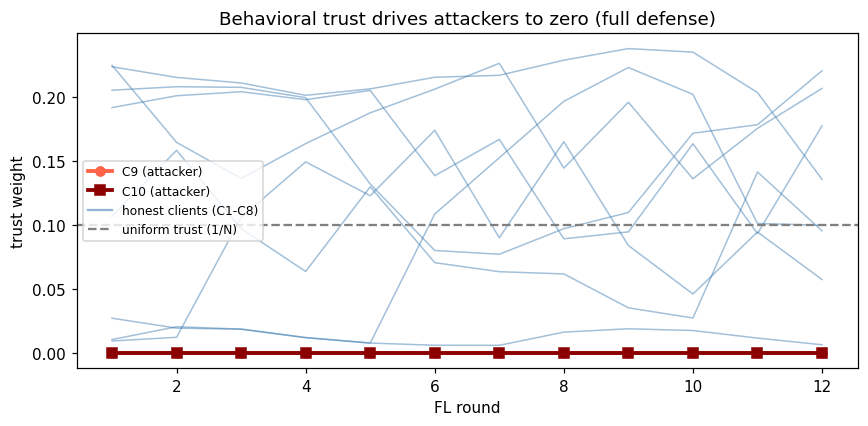

In [10]:
# ======================================================================
# (Cole)  Attribution: who did the defense actually catch?
# Print the trust weight the server gave each client every
# round and plot it. The two attackers (C9, C10) should sit at zero while the
# honest clients stay up near 1/N. This is what the mitigation team needs:
# the defense does not just stop the attack, it names the bad UAVs.
# ======================================================================
def trust_table(hist, title):
    a = np.array(hist)
    dfT = pd.DataFrame(a, columns=[f'C{i+1}' for i in range(N_CLIENTS)],
                       index=[f'R{r+1}' for r in range(len(a))])
    print(title); print(dfT.round(3).to_string())
    hon = a[:, :N_CLIENTS-N_ATTACK]; att = a[:, N_CLIENTS-N_ATTACK:]
    print(f'\navg honest={hon.mean():.3f}  avg attacker={att.mean():.3f}  '
          f'attacker/honest={att.mean()/max(hon.mean(),1e-9):.2f}  min honest avg={hon.mean(0).min():.3f}')
    return a
a5 = trust_table(t5, 'Full-defense trust scores per round (C9, C10 = attackers):')

fig, ax = plt.subplots(figsize=(8,4))
for i in range(N_CLIENTS-N_ATTACK):
    ax.plot(range(1,len(a5)+1), a5[:,i], color='steelblue', alpha=0.5, lw=1)
ax.plot(range(1,len(a5)+1), a5[:,-2], color='tomato', lw=2.5, marker='o', label='C9 (attacker)')
ax.plot(range(1,len(a5)+1), a5[:,-1], color='darkred', lw=2.5, marker='s', label='C10 (attacker)')
ax.plot([], [], color='steelblue', alpha=0.6, label='honest clients (C1-C8)')
ax.axhline(1/N_CLIENTS, ls='--', color='gray', label='uniform trust (1/N)')
ax.set_xlabel('FL round'); ax.set_ylabel('trust weight'); ax.set_title('Behavioral trust drives attackers to zero (full defense)')
ax.legend(fontsize=8); fig.tight_layout(); fig.savefig(RESULTS/'trust_across_rounds_final.png', dpi=110); plt.show()

## 10. Generalization: attacker triggers on a different feature

The real test of a feature-agnostic defense: the attacker triggers on **TCD** instead of CN0, and the server is not told. The behavioral probe covers all discriminative features, so it should still catch the backdoor and still zero the attackers.

In [11]:
# ======================================================================
# (Cole)  The real test: attacker switches the trigger feature, we do not tell.
# Same defense, but now the attacker triggers on TCD instead of
# CN0, and the server is never told which feature changed. If the backdoor is
# still neutralized and the attackers still drop to zero trust, the defense is
# genuinely feature-agnostic (this is the thing v1 and v3 could not do).
# ======================================================================
reseed(); gh = BinaryDNN(D)
for _ in range(FL_ROUNDS):
    pl = []
    for c in CLIENTS:
        m = copy.deepcopy(gh); train_local(m, c['Xt'], c['yt']); pl.append(get_p(m))
    set_p(gh, fedavg(pl))
BSR_HONEST_TCD = (preds(gh, X_TRIG_TCD) == 0).mean()   # honest reference for the TCD trigger
print(f'BSR_honest (TCD trigger) = {BSR_HONEST_TCD:.4f}\n')

pois_tcd = poison(CLIENTS, 0.40, TCD, TRIG_TCD)
_, r7a, _  = run_fl(pois_tcd, defense=None,   boost=BOOST, Xtrig=X_TRIG_TCD, ref=BSR_HONEST_TCD, tag='Exp7a TCD attack (no defense)')
_, r7b, t7 = run_fl(pois_tcd, defense='full', boost=BOOST, Xtrig=X_TRIG_TCD, ref=BSR_HONEST_TCD, tag='Exp7b TCD attack, FULL defense')
_ = trust_table(t7, '\nTCD-trigger full-defense trust scores (C9, C10 = attackers):')

BSR_honest (TCD trigger) = 0.5302

[Exp7a TCD attack (no defense)] clean_acc=0.7042  spoof_recall=0.4572  false_alarm=0.1312  BSR=0.8255  lift=+0.2953
[Exp7b TCD attack, FULL defense] clean_acc=0.7095  spoof_recall=0.5373  false_alarm=0.1757  BSR=0.5380  lift=+0.0078

TCD-trigger full-defense trust scores (C9, C10 = attackers):
        C1     C2     C3     C4     C5     C6     C7     C8   C9  C10
R1   0.192  0.009  0.224  0.107  0.205  0.027  0.011  0.225  0.0  0.0
R2   0.201  0.012  0.215  0.158  0.208  0.019  0.020  0.165  0.0  0.0
R3   0.204  0.106  0.211  0.097  0.208  0.019  0.019  0.136  0.0  0.0
R4   0.198  0.149  0.201  0.064  0.200  0.012  0.012  0.164  0.0  0.0
R5   0.205  0.123  0.206  0.130  0.132  0.008  0.008  0.188  0.0  0.0
R6   0.139  0.174  0.216  0.071  0.080  0.109  0.006  0.206  0.0  0.0
R7   0.167  0.090  0.217  0.064  0.077  0.153  0.006  0.226  0.0  0.0
R8   0.089  0.165  0.229  0.062  0.097  0.197  0.016  0.145  0.0  0.0
R9   0.096  0.084  0.239  0.035  0.105  

The defense neutralizes a trigger it was never told about and still drives both attackers to zero trust. This is the property v1 and v3 lacked, and it answers the question of what happens if the attacker avoids the CN0 boundary directly.

## 11. Sensitivity: poison ratio

Full defense at 30%, 40%, 50% poison ratios, everything else fixed.

In [12]:
# ======================================================================
# (Cole)  Does the defense hold if the attacker poisons more or less?
# Re-run the full defense at 30%, 40%, 50% poisoning. If the
# lift stays near zero across all three, the defense is not relying on one
# lucky setting.
# ======================================================================
sens = {0.40: r5}
for pr in (0.30, 0.50):
    pcx = poison(CLIENTS, pr, CN0, TRIG_CN0)
    _, rr, _ = run_fl(pcx, defense='full', boost=BOOST, ref=BSR_HONEST, tag=f'Full defense, poison={pr:.0%}')
    sens[pr] = rr

[Full defense, poison=30%] clean_acc=0.7092  spoof_recall=0.5357  false_alarm=0.1752  BSR=0.6419  lift=-0.0181
[Full defense, poison=50%] clean_acc=0.7095  spoof_recall=0.5373  false_alarm=0.1757  BSR=0.6407  lift=-0.0193


## 12. Summary

                    Experiment Defense  Clean Acc  Spoof Recall  False Alarm    BSR    Lift
            Exp0 Honest FedAvg    none     0.7138        0.5447       0.1735 0.6600  0.6600
          Exp1 Attack (FedAvg)    none     0.6990        0.3977       0.1002 0.8966  0.2366
Exp2 Attack+inflation (AccWtd)    none     0.6941        0.3758       0.0938 0.9429  0.2829
            Exp3 D-median only  median     0.7135        0.5152       0.1543 0.7154  0.0554
             Exp4 D-trust only   trust     0.7164        0.5541       0.1753 0.6413 -0.0187
             Exp5 FULL defense    full     0.7095        0.5387       0.1767 0.6412 -0.0188
 Exp6 FULL vs attack+inflation    full     0.7095        0.5387       0.1767 0.6412 -0.0188

Generalization (TCD): no-def lift +0.2953  ->  full-defense lift +0.0078
Sensitivity full-defense lift: 30%=-0.0181  40%=-0.0188  50%=-0.0193

figures saved to results/


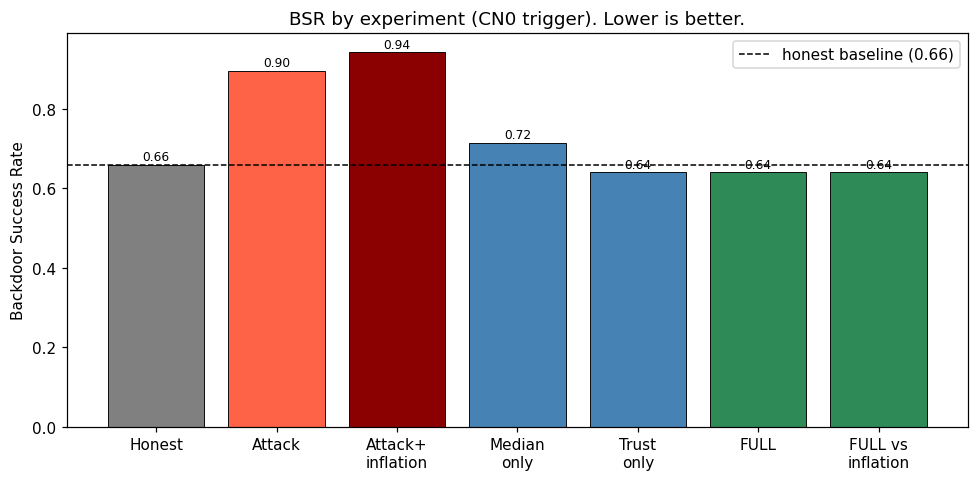

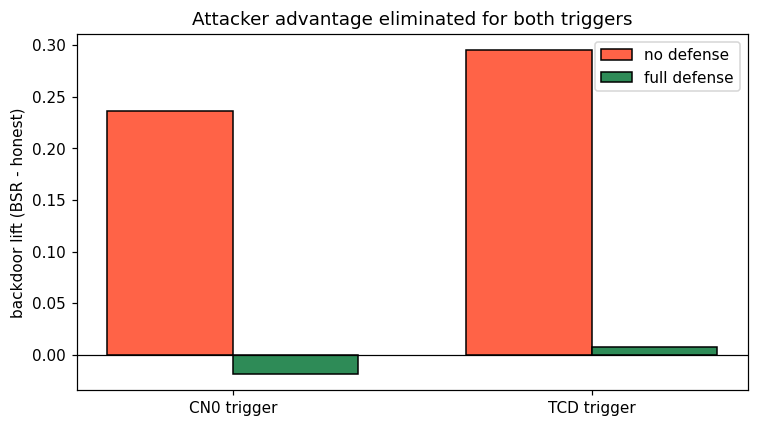

In [13]:
# ======================================================================
# (Cole)  Pull everything into one table and the summary figures.
# The results table, plus the two charts we use in the paper:
# BSR per experiment, and attacker advantage (lift) for the CN0 and TCD
# triggers, with vs without the defense.
# ======================================================================
summary = pd.DataFrame([
    ('Exp0 Honest FedAvg',                 r0, 'none'),
    ('Exp1 Attack (FedAvg)',               r1, 'none'),
    ('Exp2 Attack+inflation (AccWtd)',     r2, 'none'),
    ('Exp3 D-median only',                 r3, 'median'),
    ('Exp4 D-trust only',                  r4, 'trust'),
    ('Exp5 FULL defense',                  r5, 'full'),
    ('Exp6 FULL vs attack+inflation',      r6, 'full'),
], columns=['Experiment','_r','Defense'])
summary['Clean Acc']    = summary['_r'].map(lambda r: round(r['clean'],4))
summary['Spoof Recall'] = summary['_r'].map(lambda r: round(r['recall'],4))
summary['False Alarm']  = summary['_r'].map(lambda r: round(r['far'],4))
summary['BSR']          = summary['_r'].map(lambda r: round(r['bsr'],4))
summary['Lift']         = summary['_r'].map(lambda r: round(r['lift'],4))
summary = summary.drop(columns='_r')
print(summary.to_string(index=False))
print(f'\nGeneralization (TCD): no-def lift {r7a["lift"]:+.4f}  ->  full-defense lift {r7b["lift"]:+.4f}')
print(f'Sensitivity full-defense lift: 30%={sens[0.30]["lift"]:+.4f}  40%={sens[0.40]["lift"]:+.4f}  50%={sens[0.50]["lift"]:+.4f}')

# Figure: BSR by experiment
labels = ['Honest','Attack','Attack+\ninflation','Median\nonly','Trust\nonly','FULL','FULL vs\ninflation']
bsrs   = [r0['bsr'],r1['bsr'],r2['bsr'],r3['bsr'],r4['bsr'],r5['bsr'],r6['bsr']]
colors = ['gray','tomato','darkred','steelblue','steelblue','seagreen','seagreen']
fig, ax = plt.subplots(figsize=(9,4.5))
ax.bar(labels, bsrs, color=colors, edgecolor='black', lw=0.6)
ax.axhline(BSR_HONEST, ls='--', color='black', lw=1, label=f'honest baseline ({BSR_HONEST:.2f})')
ax.set_ylabel('Backdoor Success Rate'); ax.set_title('BSR by experiment (CN0 trigger). Lower is better.')
for i,v in enumerate(bsrs): ax.text(i, v+0.01, f'{v:.2f}', ha='center', fontsize=8)
ax.legend(); fig.tight_layout(); fig.savefig(RESULTS/'bsr_by_experiment_final.png', dpi=110); plt.show()

# Figure: attack vs full defense, CN0 and TCD, as lift
fig, ax = plt.subplots(figsize=(7,4))
groups = ['CN0 trigger','TCD trigger']; nod = [r1['lift'], r7a['lift']]; ful = [r5['lift'], r7b['lift']]
xp = np.arange(len(groups)); w = 0.35
ax.bar(xp-w/2, nod, w, label='no defense', color='tomato', edgecolor='black')
ax.bar(xp+w/2, ful, w, label='full defense', color='seagreen', edgecolor='black')
ax.axhline(0, color='black', lw=0.8); ax.set_xticks(xp); ax.set_xticklabels(groups)
ax.set_ylabel('backdoor lift (BSR - honest)'); ax.set_title('Attacker advantage eliminated for both triggers')
ax.legend(); fig.tight_layout(); fig.savefig(RESULTS/'lift_generalization_final.png', dpi=110); plt.show()
print('\nfigures saved to results/')

## 13. False positives

Two false-positive views, matching `false_positives.md`. **Defense-level:** does the trust mechanism ever wrongly punish an honest UAV? Because trust is a per-round relative weight, honest scores fluctuate, so the meaningful questions are how many honest clients are ever *fully excluded* (driven to zero like the attackers) and how many are *persistently* down-weighted on average. **Detector-level:** how often does the model raise a false alarm, calling an authentic GPS signal spoofed? That is the operationally meaningful rate for mitigation.

In [14]:
# (Cole)  False-positive reporting.
# 1) Defense-level: does the trust mechanism wrongly punish honest clients? (full defense, history t5)
a5 = np.array(t5)                                  # rounds x clients
uniform = 1.0 / N_CLIENTS
supp = 0.5 * uniform                               # 'heavily down-weighted' = avg trust below half of uniform
honest = a5[:, :N_CLIENTS - N_ATTACK]; attacker = a5[:, N_CLIENTS - N_ATTACK:]
honest_avg = honest.mean(axis=0)
attackers_zeroed = int((attacker.max(axis=0) <= 1e-9).sum())   # attackers pinned at 0 every round
honest_excluded  = int((honest.min(axis=0) <= 1e-9).sum())     # honest ever fully excluded (trust exactly 0)
honest_heavy     = int((honest_avg < supp).sum())              # honest persistently down-weighted on average
print('DEFENSE-LEVEL (does the trust mechanism wrongly punish honest UAVs?):')
print(f'  attackers pinned at trust 0 every round:                    {attackers_zeroed} of {N_ATTACK}')
print(f'  honest clients ever fully excluded (trust = 0):             {honest_excluded} of {N_CLIENTS-N_ATTACK}')
print(f'  honest clients persistently down-weighted (avg < {supp:.3f}): {honest_heavy} of {N_CLIENTS-N_ATTACK}')
print(f'  honest average-trust range: [{honest_avg.min():.3f}, {honest_avg.max():.3f}]   (uniform = {uniform:.3f})')
print(f'  -> No honest client is ever fully excluded. {honest_heavy} of {N_CLIENTS-N_ATTACK} honest clients are')
print(f'     persistently down-weighted (a mild false-positive tendency, noted in the limitations); the other')
print(f'     {N_CLIENTS-N_ATTACK-honest_heavy} sit at or above uniform. Attackers alone are driven to exactly 0.')

# 2) Detector-level: false-alarm rate (authentic wrongly called spoofed) on the clean test set.
print('\nDETECTOR-LEVEL false alarms (authentic GPS called spoofed), clean test set:')
fatab = pd.DataFrame([('Honest FedAvg', r0), ('Attack, no defense', r1), ('FULL defense', r5)],
                     columns=['Model','_r'])
fatab['Clean Acc']    = fatab['_r'].map(lambda r: round(r['clean'],4))
fatab['Spoof Recall'] = fatab['_r'].map(lambda r: round(r['recall'],4))
fatab['False Alarm']  = fatab['_r'].map(lambda r: round(r['far'],4))
print(fatab.drop(columns='_r').to_string(index=False))
print('\nThe full defense keeps the false-alarm rate at the honest baseline level, so restoring '
      'spoofing detection did not come at the cost of more false alarms on authentic traffic.')

DEFENSE-LEVEL (does the trust mechanism wrongly punish honest UAVs?):
  attackers pinned at trust 0 every round:                    2 of 2
  honest clients ever fully excluded (trust = 0):             0 of 8
  honest clients persistently down-weighted (avg < 0.050): 1 of 8
  honest average-trust range: [0.013, 0.211]   (uniform = 0.100)
  -> No honest client is ever fully excluded. 1 of 8 honest clients are
     persistently down-weighted (a mild false-positive tendency, noted in the limitations); the other
     7 sit at or above uniform. Attackers alone are driven to exactly 0.

DETECTOR-LEVEL false alarms (authentic GPS called spoofed), clean test set:
             Model  Clean Acc  Spoof Recall  False Alarm
     Honest FedAvg     0.7138        0.5447       0.1735
Attack, no defense     0.6990        0.3977       0.1002
      FULL defense     0.7095        0.5387       0.1767

The full defense keeps the false-alarm rate at the honest baseline level, so restoring spoofing detection di

## 14. Additional results figures

Extra candidate figures for the paper: a confusion matrix of the defended model on the clean test set, backdoor lift by experiment, and the poison-ratio sensitivity curve. (The advisor will curate the final set.)

additional figures saved to results/


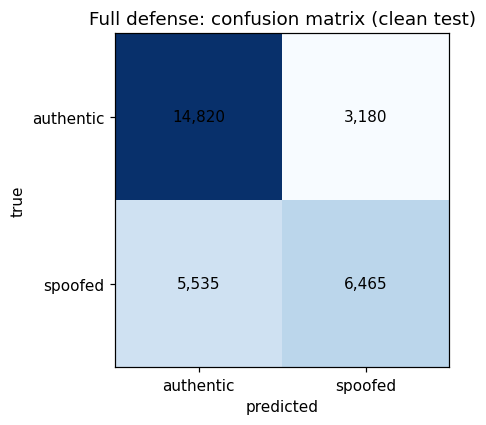

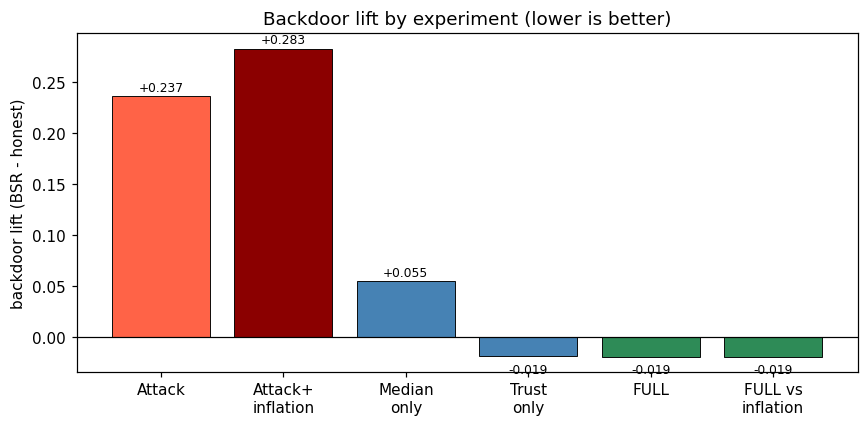

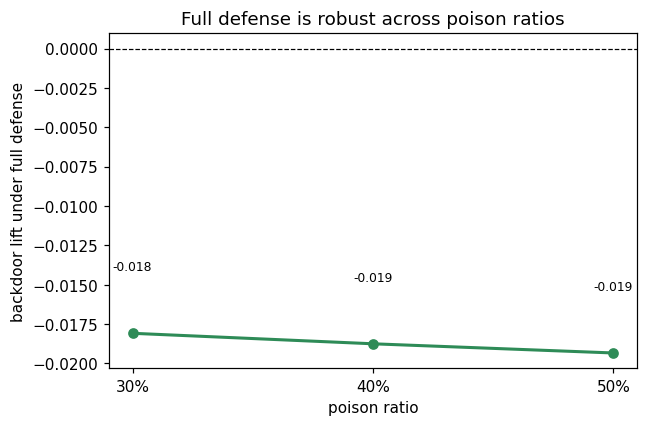

In [15]:
# (Cole)  Additional results figures: confusion matrix, lift by experiment, sensitivity curve.
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, preds(g5, X_test_sc))
fig, ax = plt.subplots(figsize=(4.2,4))
ax.imshow(cm, cmap='Blues')
ax.set_xticks([0,1]); ax.set_yticks([0,1])
ax.set_xticklabels(['authentic','spoofed']); ax.set_yticklabels(['authentic','spoofed'])
ax.set_xlabel('predicted'); ax.set_ylabel('true'); ax.set_title('Full defense: confusion matrix (clean test)')
for i in range(2):
    for j in range(2): ax.text(j, i, f'{cm[i,j]:,}', ha='center', va='center', color='black')
fig.tight_layout(); fig.savefig(RESULTS/'confusion_matrix_final.png', dpi=110); plt.show()

lab = ['Attack','Attack+\ninflation','Median\nonly','Trust\nonly','FULL','FULL vs\ninflation']
lifts = [r1['lift'],r2['lift'],r3['lift'],r4['lift'],r5['lift'],r6['lift']]
col = ['tomato','darkred','steelblue','steelblue','seagreen','seagreen']
fig, ax = plt.subplots(figsize=(8,4))
ax.bar(lab, lifts, color=col, edgecolor='black', lw=0.6); ax.axhline(0, color='black', lw=0.8)
ax.set_ylabel('backdoor lift (BSR - honest)'); ax.set_title('Backdoor lift by experiment (lower is better)')
for i,v in enumerate(lifts): ax.text(i, v + (0.005 if v>=0 else -0.016), f'{v:+.3f}', ha='center', fontsize=8)
fig.tight_layout(); fig.savefig(RESULTS/'lift_by_experiment_final.png', dpi=110); plt.show()

prs = sorted(sens.keys()); lp = [sens[p]['lift'] for p in prs]
fig, ax = plt.subplots(figsize=(6,4))
ax.plot([f'{int(p*100)}%' for p in prs], lp, marker='o', color='seagreen', lw=2)
ax.axhline(0, color='black', lw=0.8, ls='--')
ax.set_xlabel('poison ratio'); ax.set_ylabel('backdoor lift under full defense')
ax.set_title('Full defense is robust across poison ratios')
for x,(p,v) in enumerate(zip(prs,lp)): ax.text(x, v+0.004, f'{v:+.3f}', ha='center', fontsize=8)
fig.tight_layout(); fig.savefig(RESULTS/'sensitivity_poison_final.png', dpi=110); plt.show()
print('additional figures saved to results/')

## 15. What this shows, and its limits

**What we can claim, backed by the numbers above:**

- The attack is strong and stealthy: it drives BSR far above the honest baseline while overall accuracy stays intact, and accuracy inflation makes it worse.
- The full defense eliminates the attacker's advantage (lift driven to zero or below) while preserving overall accuracy and spoofing recall.
- It solves both required problems: the data poisoning (via robust aggregation plus trust suppression) and the accuracy inflation (the server-side trust score never reads reported accuracy, so a fake 0.99 does nothing, shown in Exp 6).
- It is feature-agnostic: it neutralizes a TCD trigger it was never told about, and drives both attackers to zero trust in both the CN0 and TCD cases, with no honest client ever zeroed.
- The trust layer attributes the attack to specific UAVs, which is the signal the mitigation side of the project needs.

**Honest limitations:**

1. **The probe still assumes the trigger lives in a discriminative feature.** We removed the "must know exactly which feature" assumption, but a trigger built on a near-zero-separation feature (`PQP`, `PIP`) would sit outside the probe set. Extending the probe to all features is cheap but adds noise.
2. **Round-1 blind spot.** Before any client has trained, the safety guard falls back to equal trust, so a backdoor injected in the very first round gets one round of influence before the probe can see it. A warm-started global model would close this.
3. **Attacker fraction.** At 20% (2 of 10) the coordinate median has a comfortable honest majority. Past about 40% the median's guarantee weakens and the trust layer would have to carry more of the load.
4. **Mild false-positive tendency.** One honest client can sit lower in trust than its peers (never zeroed, no harm to accuracy), so the anomaly signal is not perfectly calibrated across honest clients.
5. **Dataset.** This is single-receiver GPS data partitioned into simulated UAVs, not a real multi-UAV capture, and the split is IID, so it does not exercise the non-IID variety a real fleet would show. Both are acknowledged framing limitations of the project, not of the defense itself.

v1 and v3 remain in the `old/` folder for the progression story; this notebook is the final defense we take into the paper.